## Лабораторна робота 4. **REGRESSION** 📈

# Опис вибірки "Motorbike Ambulance Calls"


Аварії за участю мотоциклів та відповідні виклики швидкої допомоги сильно залежать від екологічних та сезонних умов, таких як погодні умови, опади, день тижня, сезон, година дня тощо. Дані збирались протягом двох років щогодини та потім співвідносилися з відповідною погодою та сезонністю.

Основні характеристики вибірки `motorbike_ambulance_calls.csv`:

              - index: record index
              - date : date
              - season : season (1:springer, 2:summer, 3:fall, 4:winter)
              - yr : year (0: 2011, 1:2012)
              - mnth : month ( 1 to 12)
              - hr : hour (0 to 23)
              - holiday : whether day is holiday or not
              - weekday : day of the week
              - workingday : if day is neither weekend nor holiday is 1, otherwise is 0.
              -  weathersit :
                      - 1: Clear, Few clouds, Partly cloudy, Partly cloudy
                      - 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
                      - 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
                      - 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
              - temp : Normalized temperature in Celsius. The values are divided to 41 (max)
              - atemp: Normalized feeling temperature in Celsius. The values are divided to 50 (max)
              - hum: Normalized humidity. The values are divided to 100 (max)
              - windspeed: Normalized wind speed. The values are divided to 67 (max)
              - cnt: count of total ambulance calls

## Імпорт необхідних бібліотек та завантаження даних

**Завдання 1** підготовка даних до опрацювання

1. завантажте вибірку `motorbike_ambulance_calls.csv`;   
2. підключіть необхідні бібліотеки;  
3. вивести основну статистичну інформацію по числовим змінним;  
4. окремо вивести максимальні та мінімальні значення по всім змінним;  
5. вивести розмірність датасету;

In [151]:
import pandas as pd
import numpy as np
import scipy as sc
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from datetime import datetime
%matplotlib inline

In [145]:
def get_data(data_path: str):
  data = pd.read_csv(data_path)
  return data

In [146]:
moto_ambu_calls = get_data("/content/motorbike_ambulance_calls.csv")
print(moto_ambu_calls.head())

   index    date  season  yr  mnth  hr  holiday  weekday  workingday  \
0      1  1/1/11  spring   0     1   0        0        6           0   
1      2  1/1/11  spring   0     1   1        0        6           0   
2      3  1/1/11  spring   0     1   2        0        6           0   
3      4  1/1/11  spring   0     1   3        0        6           0   
4      5  1/1/11  spring   0     1   4        0        6           0   

   weathersit  temp   atemp   hum  windspeed  cnt  
0           1  0.24  0.2879  0.81        0.0   16  
1           1  0.22  0.2727  0.80        0.0   40  
2           1  0.22  0.2727  0.80        0.0   32  
3           1  0.24  0.2879  0.75        0.0   13  
4           1  0.24  0.2879  0.75        0.0    1  


**Завдання 2** перевірити типи даних та перевірте кількість даних по кожній змінній.

In [147]:
print(moto_ambu_calls.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   index       17379 non-null  int64  
 1   date        17379 non-null  object 
 2   season      17379 non-null  object 
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  cnt         17379 non-null  int64  
dtypes: float64(4), int64(9), object(2)
memory usage: 2.0+ MB
None


**Завдання 3** пепевірте всі змінні на наявність пропусків.

In [148]:
print(moto_ambu_calls.isnull().sum())

index         0
date          0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64


**Висновки з 1-3 завдання (детальні)**


1.  у завданні 1 можна побачити дані про погодні умови, сезони і кількість викликів.
2.  Загалом в таблиці 15 стоваців з типами даних: int64(9:index, yr, mnth, hr, holiday, weekday, workingday, weathersit, cnt),float64(4:temp, atemp, hum, windspeed),object(2:date, season). Також всі стовпці немають null значень.
3. Як я згадувала у попередньому завданні у таблиці немає null значень.




**Завдання 4** перетворіть змінну `date` в **date type**. Визначте часові межі датасету.

In [165]:
def tranform_date(df: pd.DataFrame, date_col_name: str):
  df[date_col_name] = pd.to_datetime(df[date_col_name])
  return df

data = tranform_date(moto_ambu_calls, 'date')
print(data.head())

   index       date  season  yr  mnth  hr  holiday  weekday  workingday  \
0      1 2011-01-01       0   0     1   0        0        6           0   
1      2 2011-01-01       0   0     1   1        0        6           0   
2      3 2011-01-01       0   0     1   2        0        6           0   
3      4 2011-01-01       0   0     1   3        0        6           0   
4      5 2011-01-01       0   0     1   4        0        6           0   

   weathersit  temp   atemp   hum  windspeed  cnt  
0           1  0.24  0.2879  0.81        0.0   16  
1           1  0.22  0.2727  0.80        0.0   40  
2           1  0.22  0.2727  0.80        0.0   32  
3           1  0.24  0.2879  0.75        0.0   13  
4           1  0.24  0.2879  0.75        0.0    1  


In [167]:
def get_time_limits(df: pd.DataFrame, date_col_name: str):
  first_day = df[date_col_name].min()
  last_day = df[date_col_name].max()
  print(f"First day of dataset - {first_day}.\n Last day of dataset - {last_day}")
get_time_limits(data, 'date')

First day of dataset - 2011-01-01 00:00:00.
 Last day of dataset - 2012-12-31 00:00:00


Змінна date була успішно перетворена. Крім того, ми знаємо, що датасет охоплює дзвінки від 01.01.2011 до 2012.12.31

In [116]:
#your conclusions

#Аналіз категоріальних змінних

**Завдання 5** виділити категоріальні змінні в окремий датасет







In [168]:
moto_calls_categorical = data[['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']]

print(moto_calls_categorical)

       season  yr  mnth  hr  holiday  weekday  workingday  weathersit
0           0   0     1   0        0        6           0           1
1           0   0     1   1        0        6           0           1
2           0   0     1   2        0        6           0           1
3           0   0     1   3        0        6           0           1
4           0   0     1   4        0        6           0           1
...       ...  ..   ...  ..      ...      ...         ...         ...
17374       0   1    12  19        0        1           1           2
17375       0   1    12  20        0        1           1           2
17376       0   1    12  21        0        1           1           1
17377       0   1    12  22        0        1           1           1
17378       0   1    12  23        0        1           1           1

[17379 rows x 8 columns]


**Завдання 6** перетворіть змінну `season` в числову шкалу.

In [169]:
def encode_season(df: pd.DataFrame, season_col_name: str):
  df[season_col_name] = pd.factorize(df[season_col_name])[0]
  return df

data = encode_season(data, 'season')
print(data.head())

   index       date  season  yr  mnth  hr  holiday  weekday  workingday  \
0      1 2011-01-01       0   0     1   0        0        6           0   
1      2 2011-01-01       0   0     1   1        0        6           0   
2      3 2011-01-01       0   0     1   2        0        6           0   
3      4 2011-01-01       0   0     1   3        0        6           0   
4      5 2011-01-01       0   0     1   4        0        6           0   

   weathersit  temp   atemp   hum  windspeed  cnt  
0           1  0.24  0.2879  0.81        0.0   16  
1           1  0.22  0.2727  0.80        0.0   40  
2           1  0.22  0.2727  0.80        0.0   32  
3           1  0.24  0.2879  0.75        0.0   13  
4           1  0.24  0.2879  0.75        0.0    1  


**Завдання 7** побудувати графіки `countplot` по всім категоріальним змінним

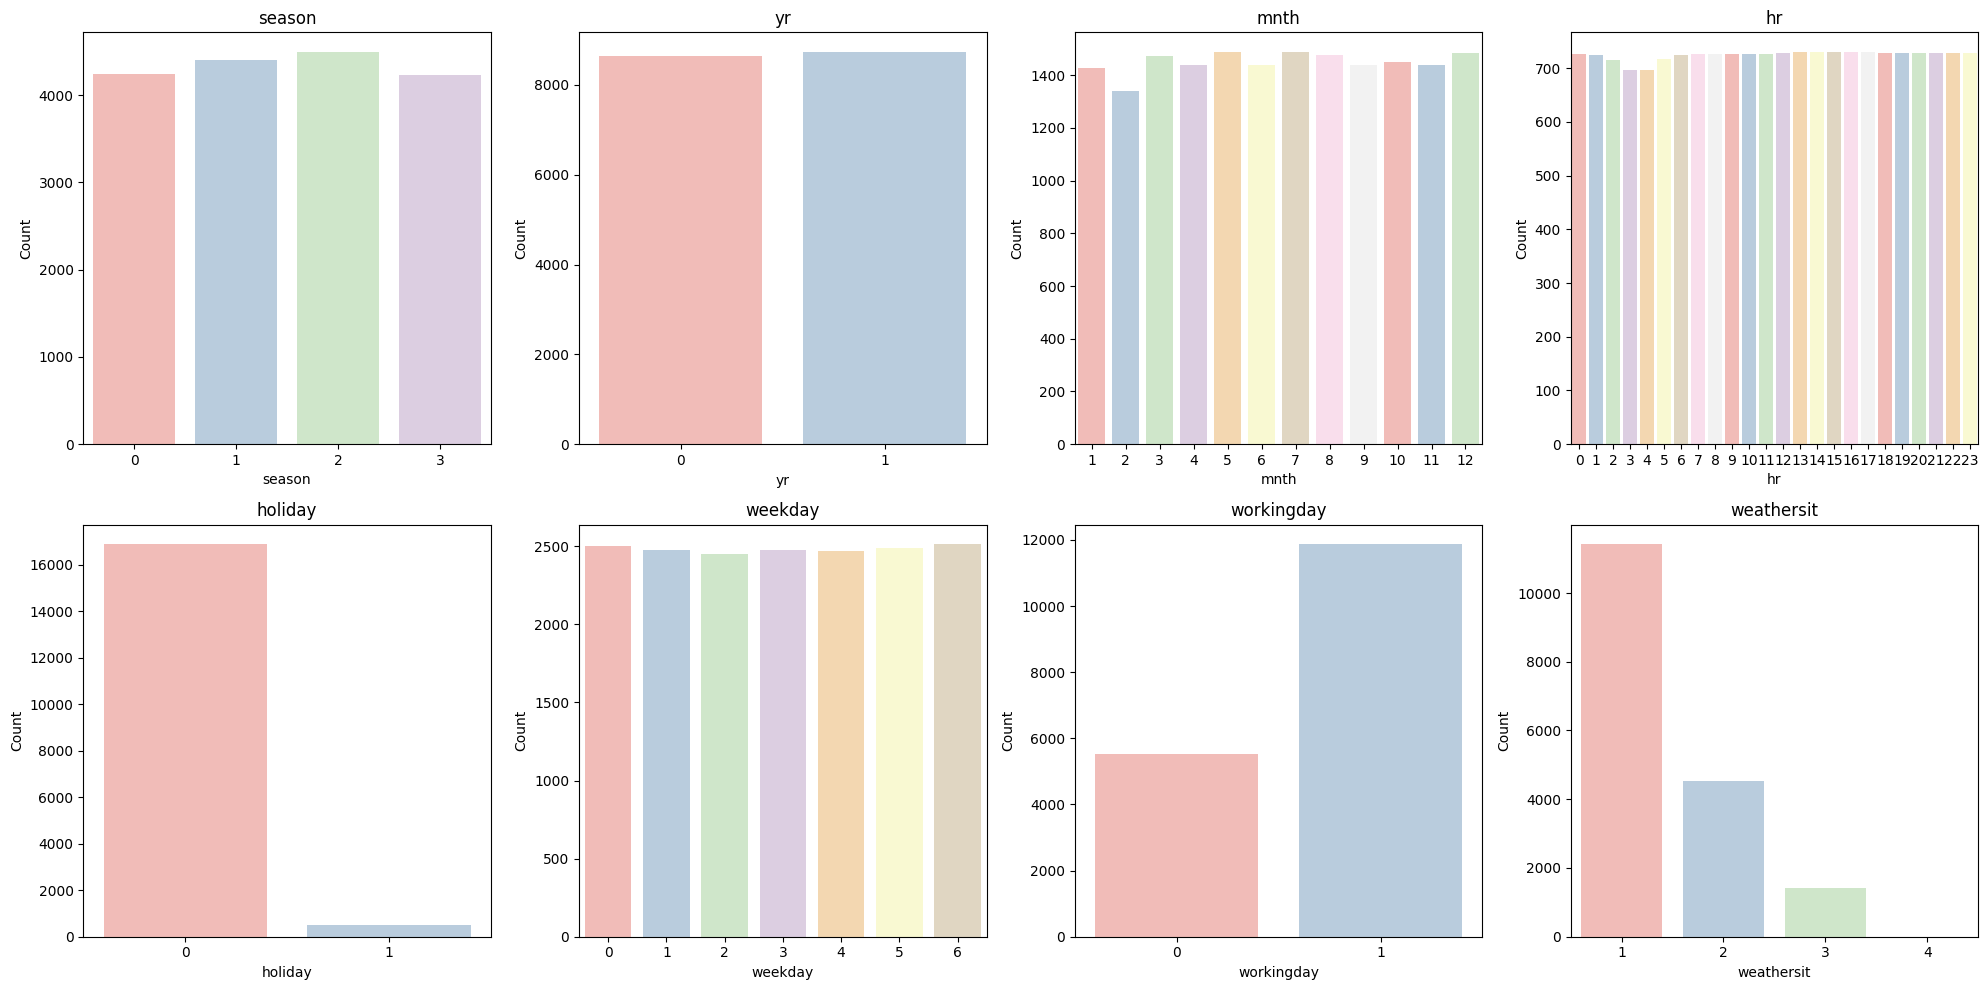

In [170]:
fig, ax = plt.subplots(2, 4, figsize=(20, 10))

for variable, subplot in zip(moto_calls_categorical, ax.flatten()):
    sns.countplot(x=moto_calls_categorical[variable], hue=moto_calls_categorical[variable], palette='Pastel1', ax=subplot, legend=False)
    subplot.set_title(f"{variable}")
    subplot.set_xlabel(variable)
    subplot.set_ylabel("Count")

plt.tight_layout()
plt.show()

**Висновки з 5-7 завдання (детальні)**



1. Ми виділили категоріальні змінні для кращого аналізу
2. Ми успішно перетвориои змінну season на числову шкалу
3. Графіки показують рівномірний розподіл сезонів, місяців і днів тижня, що показує стабільний збір даних. Години також представлені без значних коливань. Святкових днів набагато менше, ніж звичайних, а більшість записів припадає на робочі дні. Погода  впливає на активність, більшість спостережень зафіксовано в гарну погоду, тоді як дощові дні менш поширені. Дані загалом збалансовані, але варто враховувати рідкісні категорії, оскільки вони можуть впливати на аналіз.



#Аналіз числових змінних

**Завдання 8** виділити числові змінні в окремий датасет

In [171]:
moto_calls_numerical = data[['temp', 'atemp', 'hum', 'windspeed', 'cnt']]
print(moto_calls_numerical)

       temp   atemp   hum  windspeed  cnt
0      0.24  0.2879  0.81     0.0000   16
1      0.22  0.2727  0.80     0.0000   40
2      0.22  0.2727  0.80     0.0000   32
3      0.24  0.2879  0.75     0.0000   13
4      0.24  0.2879  0.75     0.0000    1
...     ...     ...   ...        ...  ...
17374  0.26  0.2576  0.60     0.1642  119
17375  0.26  0.2576  0.60     0.1642   89
17376  0.26  0.2576  0.60     0.1642   90
17377  0.26  0.2727  0.56     0.1343   61
17378  0.26  0.2727  0.65     0.1343   49

[17379 rows x 5 columns]


**Завдання 9** побудуйте гістограми розподілу по всім числовим змінним

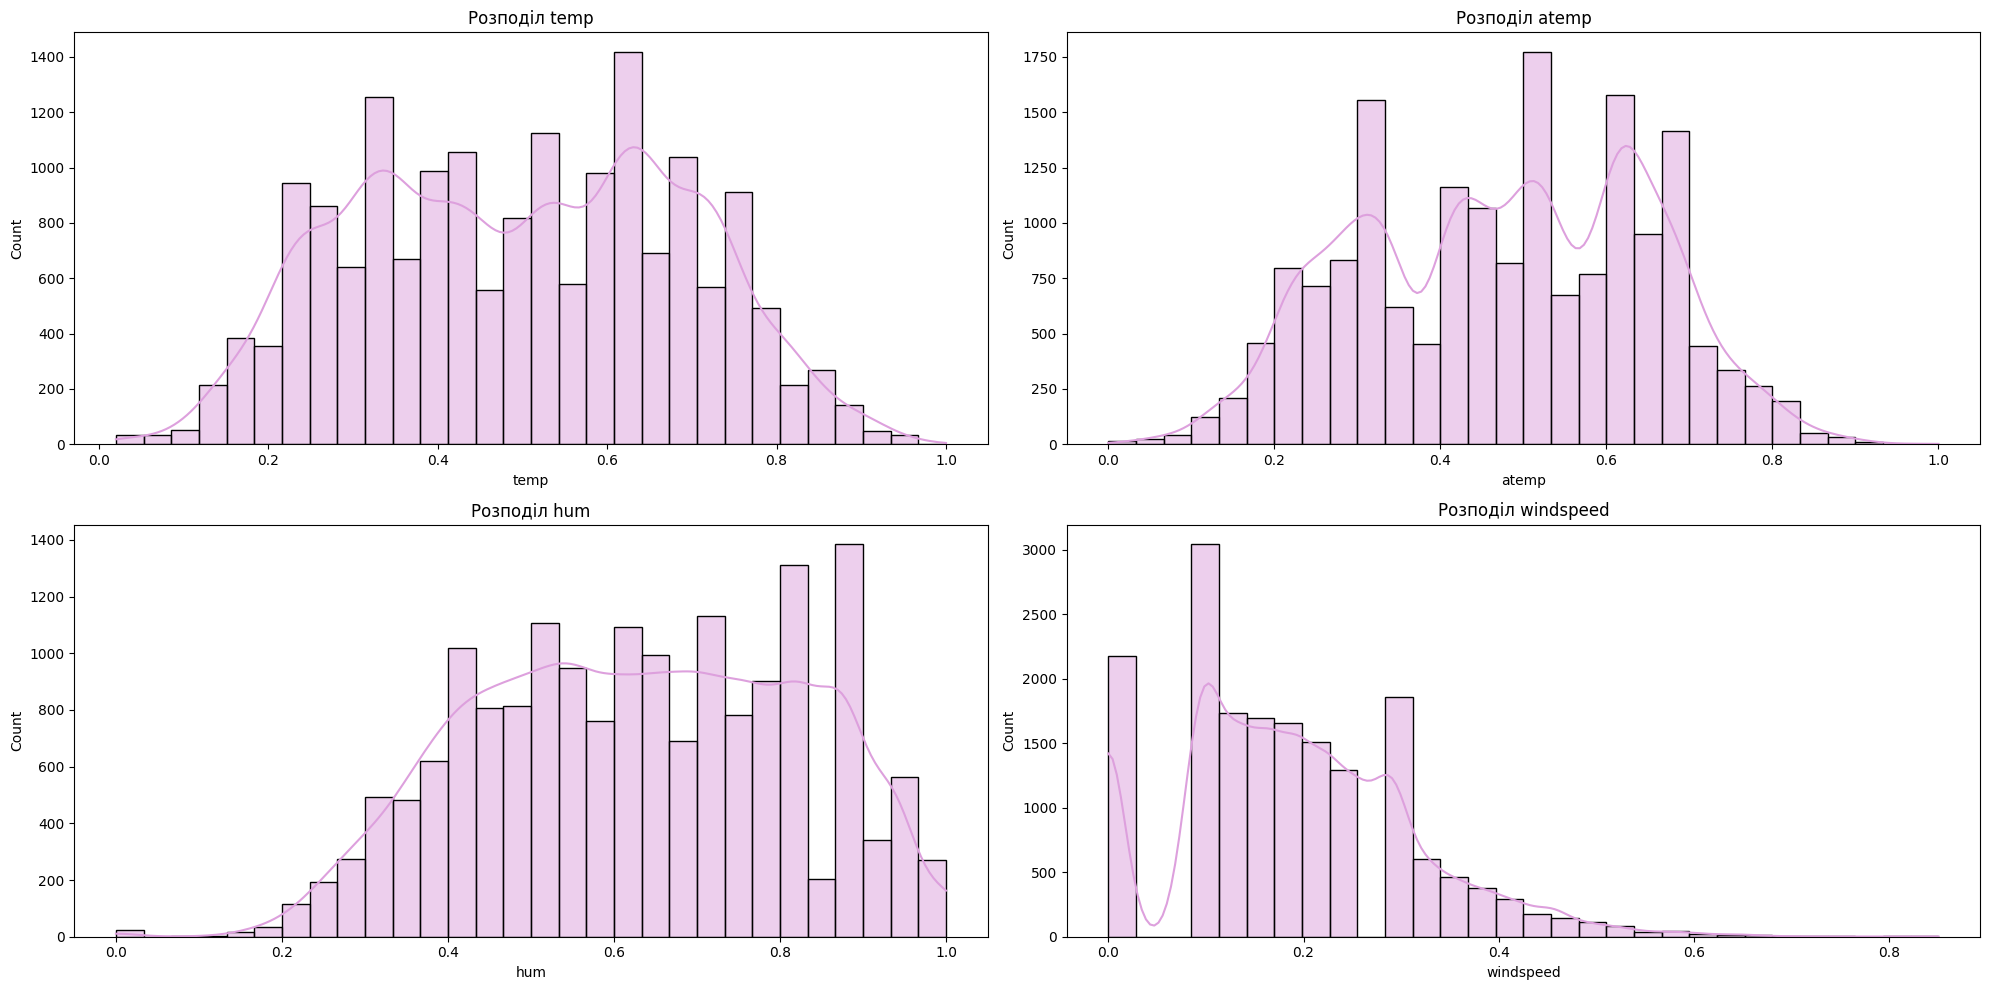

In [172]:
fig, ax = plt.subplots(2, 2, figsize=(20, 10))
for variable, ax in zip(moto_calls_numerical,  ax.flatten()):
    sns.histplot(data=data, x=variable, bins=30, kde=True, color="plum", ax=ax)
    ax.set_title(f"Розподіл {variable}")

plt.tight_layout()
plt.show()

**Завдання 10** побудуйте гістограму розподілу цільової змінної та розрахуйте коефіціент нахилу

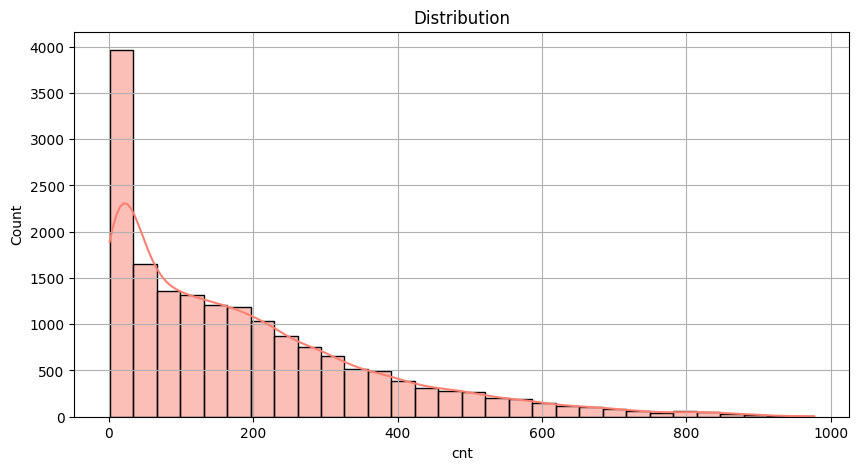

1.2774


In [173]:
plt.figure(figsize=(10, 5))
sns.histplot(data['cnt'], bins=30, kde=True, color="salmon")
plt.title("Distribution")
plt.grid(True)
plt.show()

skewness = data['cnt'].skew()
print(f"{skewness:.4f}")


**Висновки з 8-10 завдання (детальні)**



1. Ми виділили числові змінні для кращого аналізу
2. Гістограми відображають розподіл числових змінних: температура і atemp мають близьку до нормальної форми з найбільшою кількістю значень у діапазоні 0.4–0.7. Вологість рівномірно розподілена, але є значна кількість спостережень із високою вологістю (більше 0.8). Швидкість вітру має скошений праворуч розподіл, з багатьма значеннями близькими до нуля. Це може свідчити про часті періоди низької вітряності.
3.  З графіка видно, що більшість значень зосереджені в діапазоні від 0 до 200, з піком кількості спостережень близько 0. Кількість спостережень різко зменшується зі збільшенням значення, і при значеннях понад 800 спостережень практично відсутні. Цей розподіл може свідчити про сильну асиметрію вліво, що характерно для даних, де більшість значень є низькими, а високі значення зустрічаються рідко.



#Аналіз взаємозв'язків між числовими і категоріальними змінними

**Завдання 11** побудуйте графіки співвідношення `scatterplot` між всіма числовими змінними і цільовою змінною `cnt`

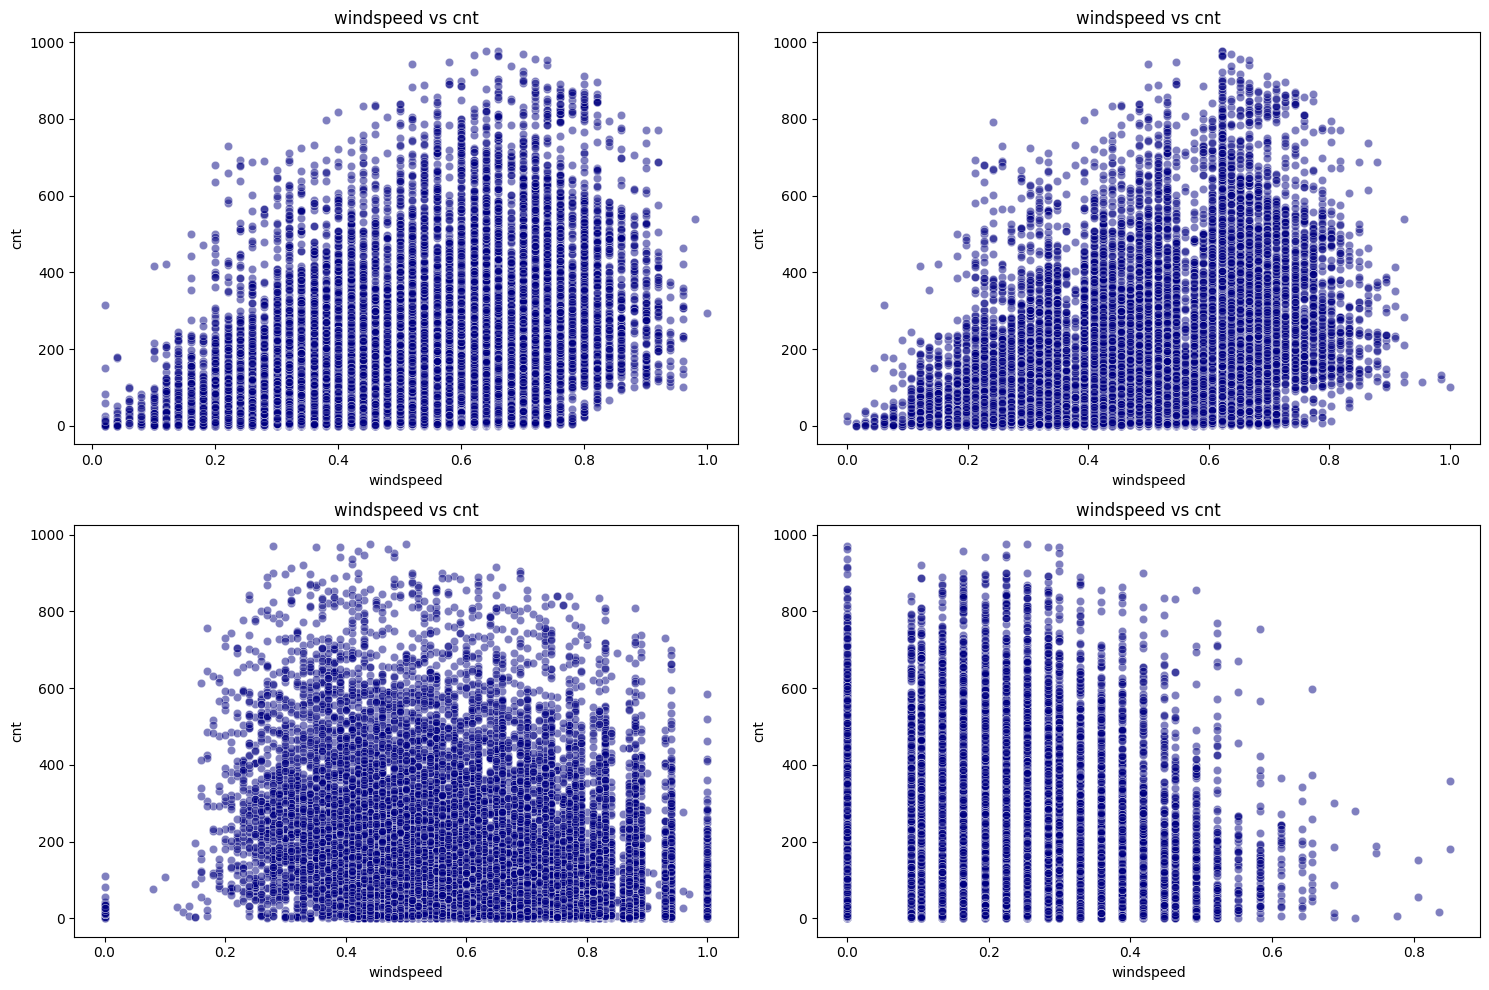

In [174]:
fig, ax = plt.subplots(2,2, figsize=(15, 10))
for var, subplot in zip(moto_calls_numerical.drop('cnt', axis =1), ax.flatten()):
    sns.scatterplot(data=data, x=var, y='cnt', alpha=0.5, color="navy", ax=subplot)
    subplot.set_title(f"{variable} vs cnt")
    subplot.set_xlabel(variable)
    subplot.set_ylabel("cnt")

plt.tight_layout()
plt.show()

**Завдання 12** побудуйте графіки співвідношення `boxplot`[boxplot](https://matplotlib.org/stable/gallery/statistics/boxplot_demo.html) між категоріальними змінними і цільовою змінною `cnt`.

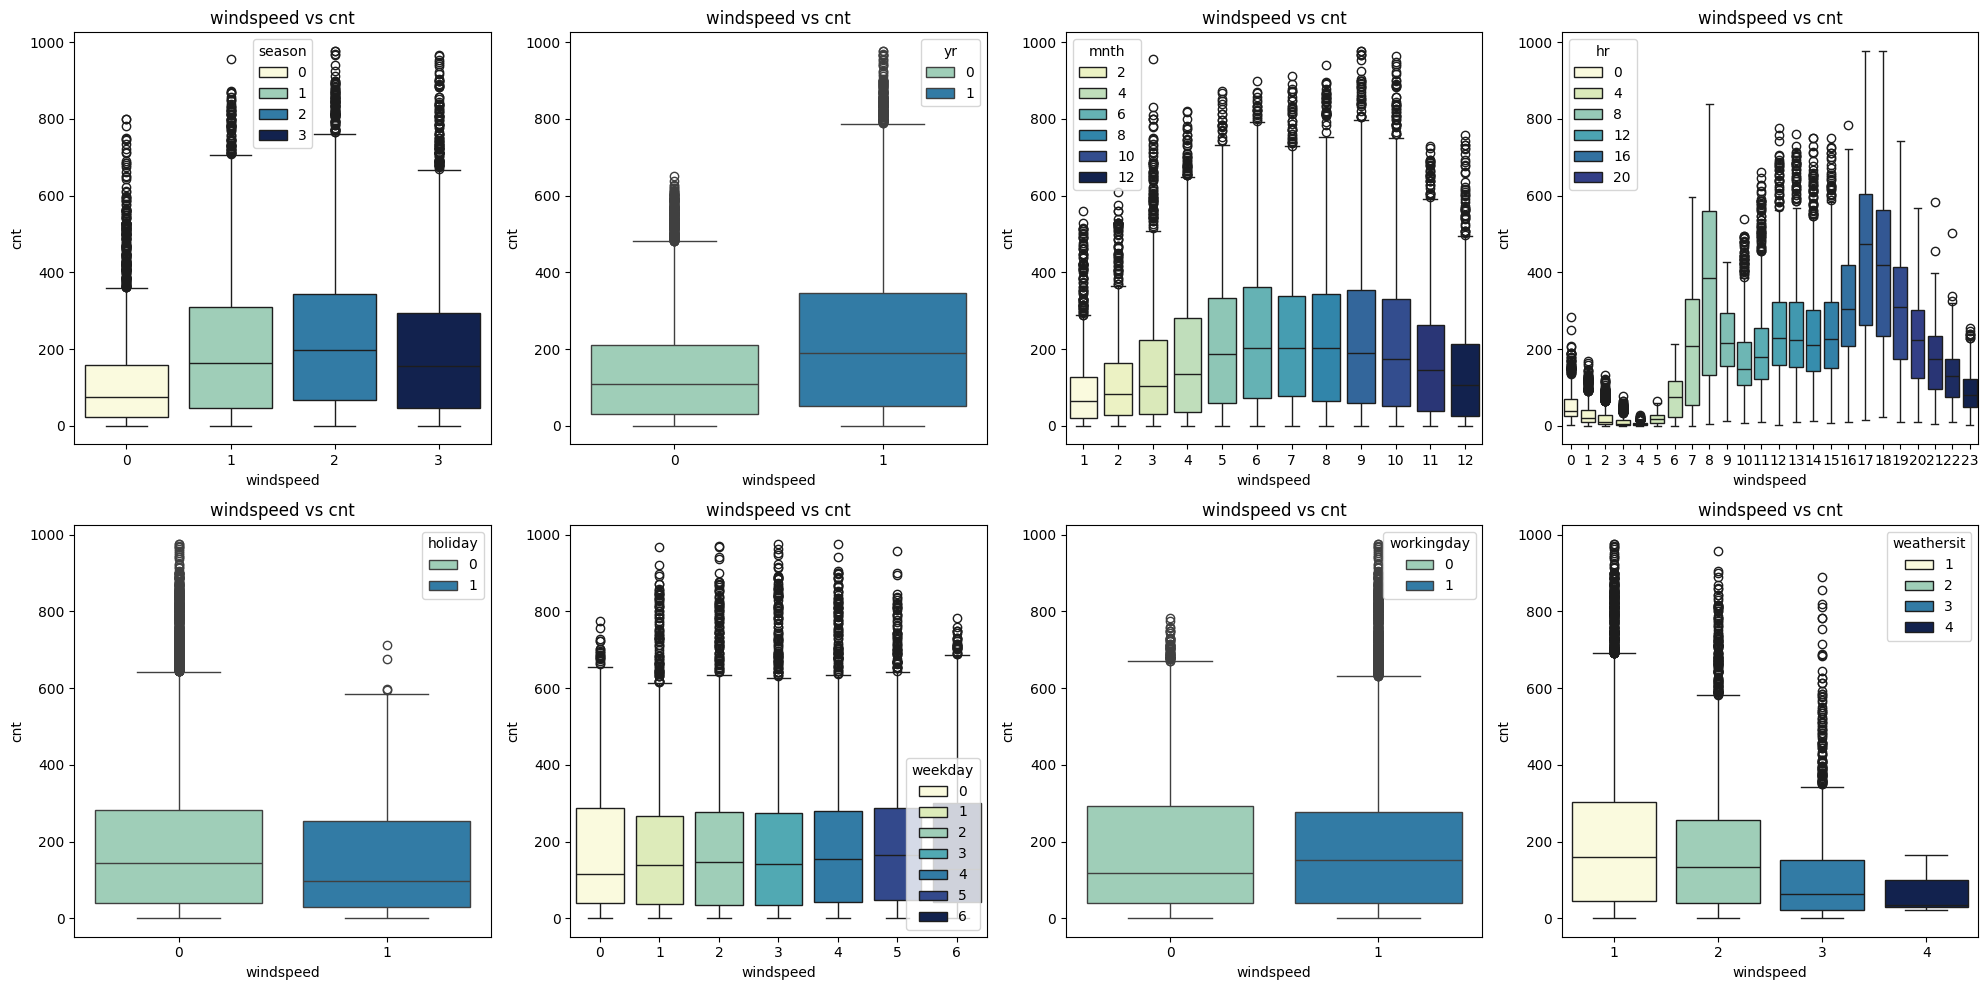

In [175]:
fig, ax = plt.subplots(2, 4, figsize=(20, 10))
for var, subplot in zip(moto_calls_categorical, ax.flatten()):
    sns.boxplot(data=data, x=var, y='cnt', palette='YlGnBu',hue=var, ax=subplot)
    subplot.set_title(f"{variable} vs cnt")
    subplot.set_xlabel(variable)
    subplot.set_ylabel("cnt")

plt.tight_layout()
plt.show()

**Висновки з 11-12 завдання (детальні)**



1. Графіки з завдання 11 показують взаємозв’язок між числовими змінними та цільовою змінною. Спостерігається чітка позитивна кореляція між температурою, atemp та кількістю дзвінків, що вказує на те, що підвищення температури повітря супроводжується збільшенням кількості викликів. Взаємозв’язок між вологістю і кількістю дзвінків менш виражений. Швидкість вітру не має явного лінійного зв’язку з кількістю дзвінків, що свідчить про слабкий вплив цього параметра на частоту викликів швидкої допомоги.
2. Графіки з завдання 12, допомагають оцінити вплив категоріальних змінних на кількість дзвінків. Спостерігається значна варіабельність кількості викликів залежно від сезону, що може свідчити про вплив погодних умов та сезонних факторів на частоту звернень. Дні тижня також демонструють певні відмінності, але без чіткої тенденції. Важливим фактором є робочі дні, оскільки в робочі дні медичні виклики можуть бути частішими через напружений ритм життя. Погодні умови  виявляють зниження кількістб дзвінків у складніших погодних умовах, що може пояснюватися зменшеною активністю населення.  




**Завдання 13** Побудувати матрицю кореляції:  

1.   Вирахувати кореляційні коефіціенти для набору данних за методом Пірсона
2.   Відобразити отриману матрицю коефіціентів у вигляді теплокарти  
3.   Вирахувати кореляційні коефіціенти для набору данних за методом Спірмана
4.   Відобразити отриману матрицю коефіціентів у вигляді теплокарти

5. Описати отримані результати, спираючись на значення коефіціентів кореляції та пояснити в чому відмінність обраних методів.

               index      date    season        yr      mnth        hr  \
index       1.000000  0.999995  0.404046  0.866014  0.489164 -0.004775   
date        0.999995  1.000000  0.404452  0.865648  0.489808 -0.006161   
season      0.404046  0.404452  1.000000 -0.010742  0.830386 -0.006117   
yr          0.866014  0.865648 -0.010742  1.000000 -0.010473 -0.003867   
mnth        0.489164  0.489808  0.830386 -0.010473  1.000000 -0.005772   
hr         -0.004775 -0.006161 -0.006117 -0.003867 -0.005772  1.000000   
holiday     0.014723  0.014737 -0.009585  0.006692  0.018430  0.000479   
weekday     0.001357  0.001372 -0.002335 -0.004485  0.010400 -0.003498   
workingday -0.003416 -0.003366  0.013743 -0.002196 -0.003477  0.002285   
weathersit -0.014198 -0.014063 -0.014524 -0.019157  0.005400 -0.020203   
temp        0.136178  0.136074  0.312025  0.040913  0.201691  0.137603   
atemp       0.137615  0.137543  0.319380  0.039222  0.208096  0.133750   
hum         0.009577  0.010196  0.1506

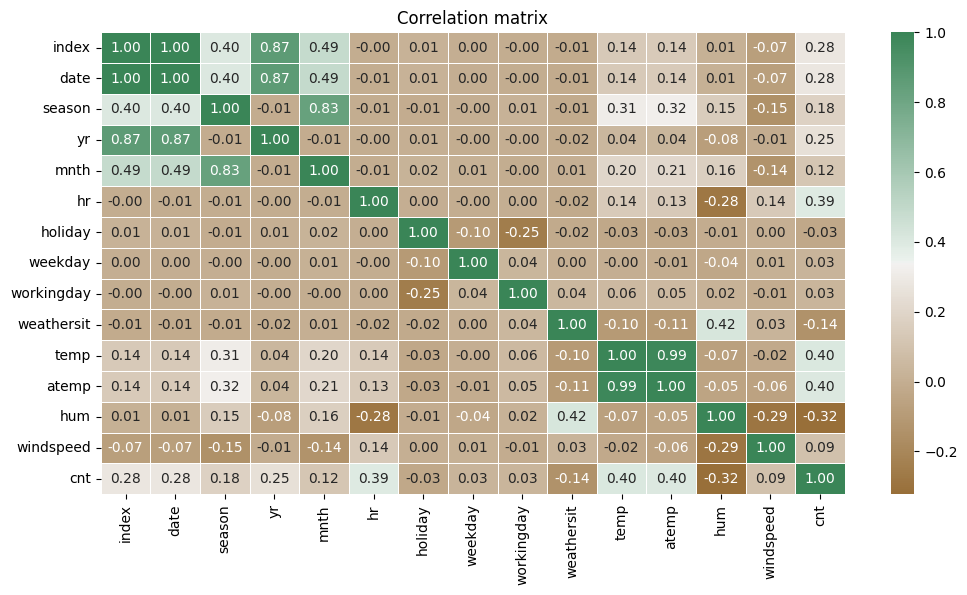

               index      date    season        yr      mnth        hr  \
index       1.000000  0.999999  0.404304  0.866014  0.489211 -0.004768   
date        0.999999  1.000000  0.404305  0.866015  0.489211 -0.006138   
season      0.404304  0.404305  1.000000 -0.010713  0.830847 -0.006092   
yr          0.866014  0.866015 -0.010713  1.000000 -0.010429 -0.003861   
mnth        0.489211  0.489211  0.830847 -0.010429  1.000000 -0.005737   
hr         -0.004768 -0.006138 -0.006092 -0.003861 -0.005737  1.000000   
holiday     0.014723  0.014724 -0.009487  0.006692  0.018695  0.000477   
weekday     0.001344  0.001344 -0.002320 -0.004493  0.010293 -0.003497   
workingday -0.003416 -0.003416  0.013671 -0.002196 -0.003653  0.002281   
weathersit -0.007462 -0.007420 -0.013335 -0.013168  0.008614 -0.030349   
temp        0.127947  0.127753  0.305753  0.036441  0.191369  0.133998   
atemp       0.126447  0.126255  0.305816  0.035346  0.190804  0.132986   
hum         0.007488  0.007870  0.1475

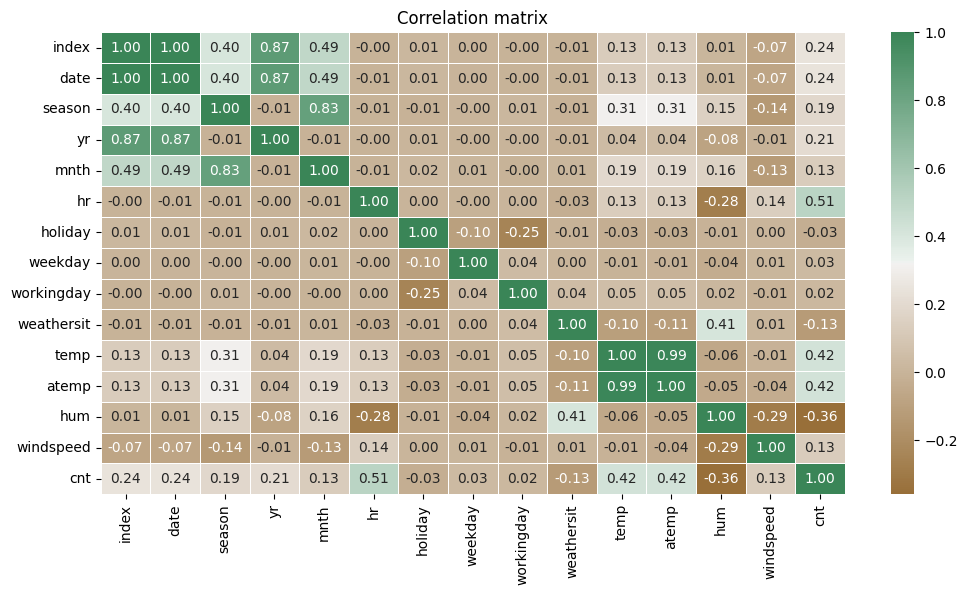

In [176]:
data_correlation_pearson = data.corr(method='pearson')
print(data_correlation_pearson)

plt.figure(figsize=(12, 6))
sns.heatmap(data_correlation_pearson, annot=True, cmap=sns.diverging_palette(50, 500, n=500), fmt=".2f", linewidths=0.5)
plt.title("Correlation matrix")
plt.show()


data_correlation_spearman = data.corr(method='spearman')
print(data_correlation_spearman)

plt.figure(figsize=(12, 6))
sns.heatmap(data_correlation_spearman, annot=True, cmap=sns.diverging_palette(50, 500, n=500), fmt=".2f", linewidths=0.5)
plt.title("Correlation matrix")
plt.show()

In [94]:
#your conclusions

Кореляційний аналіз за методом Пірсона показав, що найбільший вплив на кількість дзвінків  мають температура , година та вологість. Температура має позитивну кореляцію з cnt (приблизно 0.40), що означає, що зі зростанням температури кількість викликів збільшується. Аналогічно, значення годин має позитивну кореляцію (приблизно 0.39), що підтверджує залежність попиту від часу доби. Натомість вологість та weathersit мають негативний вплив на кількість дзвінків (-0.32 та -0.14), що свідчить про зниження попиту при підвищеній вологості та поганих погодних умовах.

Аналіз за методом Спірмана демонструє подібні закономірності, проте деякі кореляційні зв’язки виявляються сильнішими. Наприклад, зв’язок між hr та cnt є більш вираженим (приблизно 0.51), що вказує на нелінійний вплив часу доби на попит.

**Завдання 14**
1. побудувати модель лінійної регресії:
2. видалити змінні, які НЕ є релевантними;

3. поділити вибірку на `train`, `test` та `validation` в пропорції `70/30`;  

4. провести навчання моделі лінійної регресії;

1. Для подальшої роботи з моделями для кожної категоріальної змінної ми створимо фіктивні змінні, щоб уникнути неправильного порядку категорій. [get_dummies](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html)

In [178]:
def get_dummies(df: pd.DataFrame):
  features = pd.concat([df,
                      pd.get_dummies(df['season'],prefix='season', drop_first=True),
                      pd.get_dummies(df['mnth'],prefix='mnth', drop_first=True),
                      pd.get_dummies(df['weekday'],prefix='weekday', drop_first=True),
                      pd.get_dummies(df['weathersit'],prefix='weathersit', drop_first=True),
                      ], axis = 1
                     )
  features = features.drop(['season',
                            'mnth',
                            'weekday',
                            'weathersit'
                            ], axis = 1)
  return features

In [179]:
features = get_dummies(data)
print(features)
print(features.columns)

       index       date  yr  hr  holiday  workingday  temp   atemp   hum  \
0          1 2011-01-01   0   0        0           0  0.24  0.2879  0.81   
1          2 2011-01-01   0   1        0           0  0.22  0.2727  0.80   
2          3 2011-01-01   0   2        0           0  0.22  0.2727  0.80   
3          4 2011-01-01   0   3        0           0  0.24  0.2879  0.75   
4          5 2011-01-01   0   4        0           0  0.24  0.2879  0.75   
...      ...        ...  ..  ..      ...         ...   ...     ...   ...   
17374  17375 2012-12-31   1  19        0           1  0.26  0.2576  0.60   
17375  17376 2012-12-31   1  20        0           1  0.26  0.2576  0.60   
17376  17377 2012-12-31   1  21        0           1  0.26  0.2576  0.60   
17377  17378 2012-12-31   1  22        0           1  0.26  0.2727  0.56   
17378  17379 2012-12-31   1  23        0           1  0.26  0.2727  0.65   

       windspeed  ...  mnth_12  weekday_1  weekday_2  weekday_3  weekday_4  \
0        

2. На основі змінної часу створіть нову змінну, яка відповідатиме за день і ніч.

In [180]:
features['night_time'] = np.where((features['hr'] >= 22) | (features['hr'] < 5), 'night', 'day')
features = features.drop('hr', axis=1)
print(features['night_time'])

0        night
1        night
2        night
3        night
4        night
         ...  
17374      day
17375      day
17376      day
17377    night
17378    night
Name: night_time, Length: 17379, dtype: object


**Модель лінійної регрессії  

[train_linear_model](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

Після отримання фіктивних змінних потрібно видалити по одній з кожної категорії, щоб запобігти мультиколінеарності. Також видаляємо ще два атрибути `date` та `atemp` - поясніть чому?

In [182]:
features_lr = features.drop(['season_2', 'mnth_4', 'weekday_1', 'weathersit_2', 'night_time','atemp', 'date'], axis = 1)


In [184]:
def get_train_data(df: pd.DataFrame, target:str, test_size:float):
  X = df.drop(columns=[target])
  y = df[target]
  X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size=test_size, random_state=42, shuffle = True)
  return X_train, X_test, y_train, y_test

In [185]:
X_train, X_test, y_train, y_test = get_train_data(features_lr, 'cnt', 0.3)

In [186]:
def train_linear_model(X_train, y_train):
  model = LinearRegression()
  model.fit(X_train, y_train)
  return model

model = train_linear_model(X_train, y_train)

In [187]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print('MSE train: {:.3f}, test: {:.3f}'.format(
        mean_squared_error(y_train, y_train_pred),
        mean_squared_error(y_test, y_test_pred)))
print('R^2 train: {:.3f}, test: {:.3f}'.format(
        r2_score(y_train, y_train_pred),
        r2_score(y_test, y_test_pred)))

MSE train: 21969.239, test: 21153.374
R^2 train: 0.343, test: 0.330


Оскільки в нашій моделі є багато незалежних змінних, ми не можемо відобразити їх залежність у двовимірному просторі, але ми можемо побудувати графік взаємозв'язку між залишками моделі та передбачуваними значеннями, що також допоможе нам оцінити якість моделі.

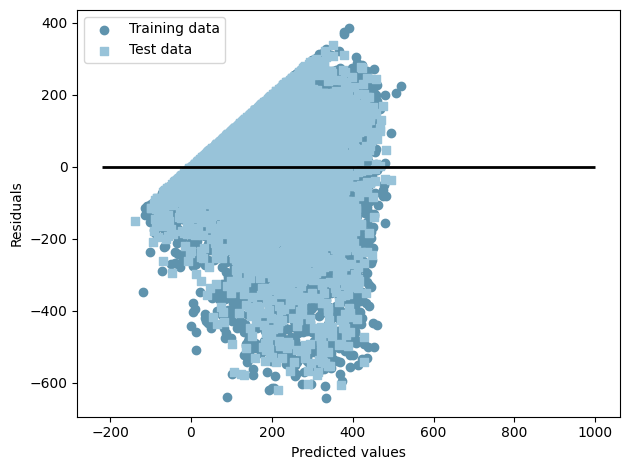

In [188]:
plt.scatter(y_train_pred,  y_train_pred - y_train,
            c='#5f93ad', marker='o', label='Training data')
plt.scatter(y_test_pred,  y_test_pred - y_test,
            c='#98c3d9', marker='s', label='Test data')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.legend(loc='upper left')
plt.hlines(y=0, xmin=-220, xmax=1000, lw=2, color='#000000')
plt.tight_layout()

**Висновки з завдання (детальні)**

Модель лінійної регресії пояснює приблизно 33% змін у кількості орендованих велосипедів. Помилка передбачень досить велика, але модель не перенавчилася, оскільки MSE для train і test майже однакові. date прибрали, бо це просто дата, atemp — бо вона схожа на temp. Видалили частину категоріальних змінних, щоб уникнути мультиколінеарності.З графіка видно, що модель працює неідеально: залишки зміщені вниз, що означає проблеми з передбаченням. Варто спробувати інші моделі або додати нові фактори.